In [10]:
# import stuff
import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
import bmg_fun
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict
import random
import matplotlib.gridspec as gridspec
import insert_hybrid

In [8]:
# species tree
S = te.species_tree_n_age(
    4, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
# gene tree
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
)
# prune all loss branches and the planted root
observable_gene_tree = te.prune_losses(T)

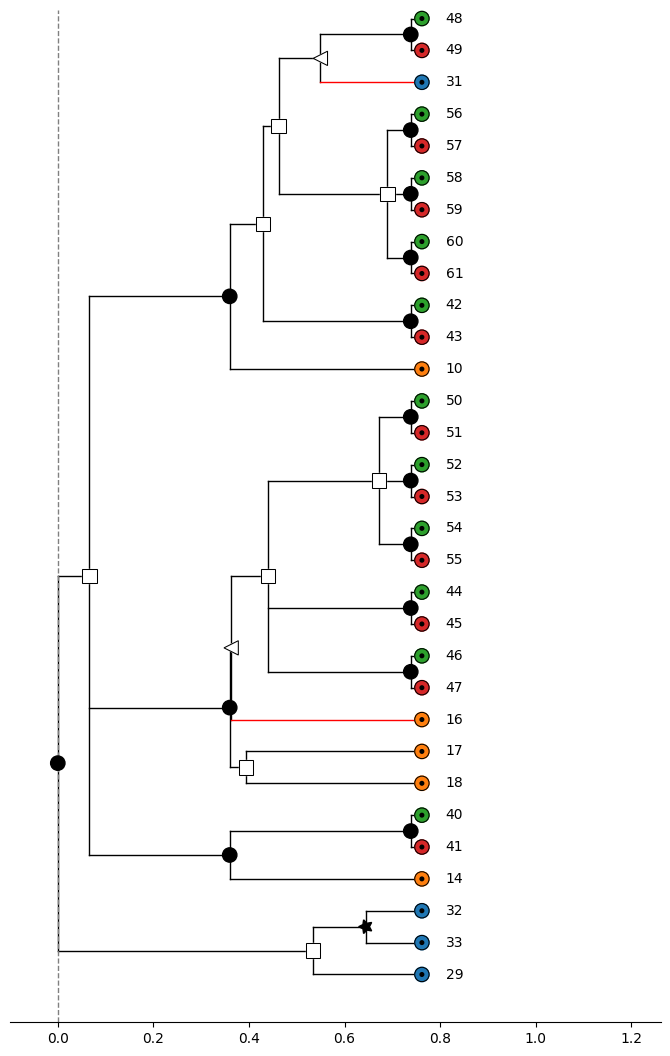

In [9]:
# get color dicts
species_colors, gene_colors = assign_colors(S, observable_gene_tree)
# visualize asymetree tree
visualize(observable_gene_tree, color_dict=gene_colors) 

In [11]:
# convert to networkx
tree_to_nx = bmg_fun.convert_to_nx(observable_gene_tree)
network = insert_hybrid.insertHybrid(tree_to_nx, 5)

Es wurde ein Hybrid zwischen node 23 und node 35 eingefügt und dieser wurde mit Node 17 verbunden
Es wurde ein Hybrid zwischen node 15 und node 21 eingefügt und dieser wurde mit Node 39 verbunden
Es wurde ein Hybrid zwischen node 11 und node 15 eingefügt und dieser wurde mit Node 37 verbunden
Es wurde ein Hybrid zwischen node 24 und node 38 eingefügt und dieser wurde mit Node 60 verbunden
Es wurde ein Hybrid zwischen node 2 und node 5 eingefügt und dieser wurde mit Node 33 verbunden


In [19]:
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)
    


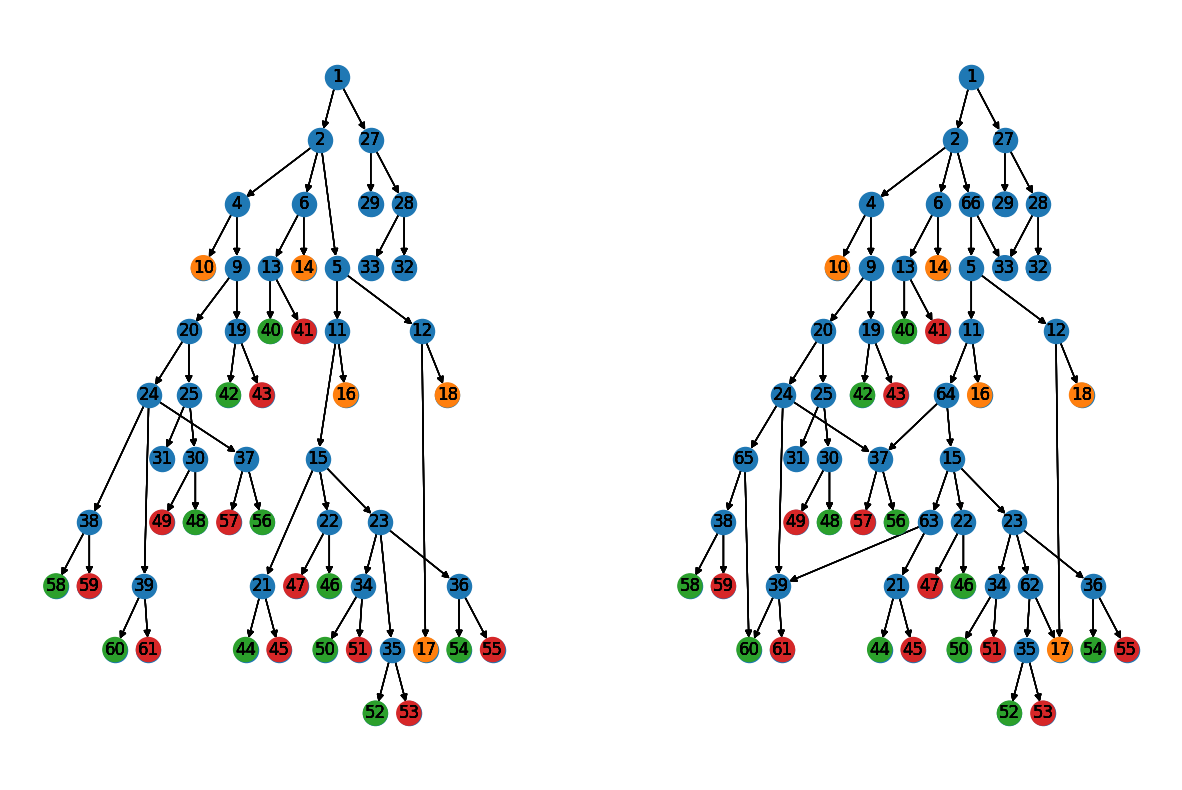

In [18]:
# visualize tree and network
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
pos = graphviz_layout(network, prog="dot")
nx.draw(tree_to_nx, pos, with_labels = True, ax=axes[0])
for color, node_list in color_to_keys.items():
    nx.draw(tree_to_nx, pos, nodelist=node_list, node_color=[color] * len(node_list), with_labels=True, ax=axes[0])

nx.draw(network, pos, with_labels = True, ax=axes[1])
for color, node_list in color_to_keys.items():
    nx.draw(network, pos, nodelist=node_list, node_color=[color] * len(node_list), with_labels=True, ax=axes[1])

# 02 Simplification of explaining networks
Construct tree-BMGs (G, σ) from (AsymmeTree-generated) trees and compute their least resolved trees T . This is the target.

In [20]:
# BMG for tree
BMG_tree = bmg_fun.compute_bmg(tree_to_nx, gene_colors)
# BMG for network
BMG_network = bmg_fun.compute_bmg(network, gene_colors)

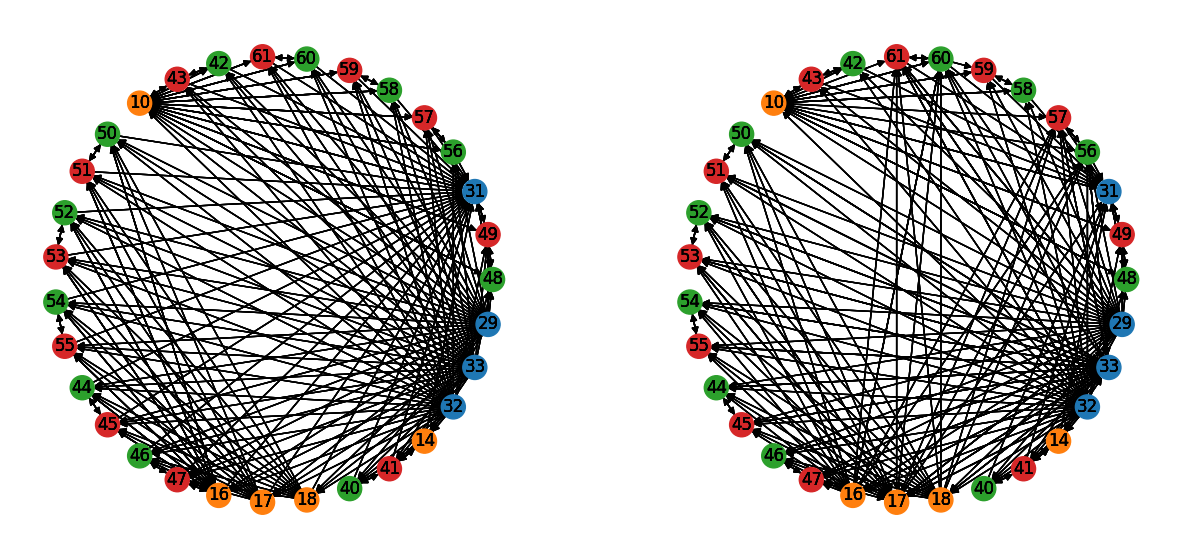

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Tree BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMG_tree, nx.circular_layout(BMG_tree), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# network BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMG_network, nx.circular_layout(BMG_network), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)

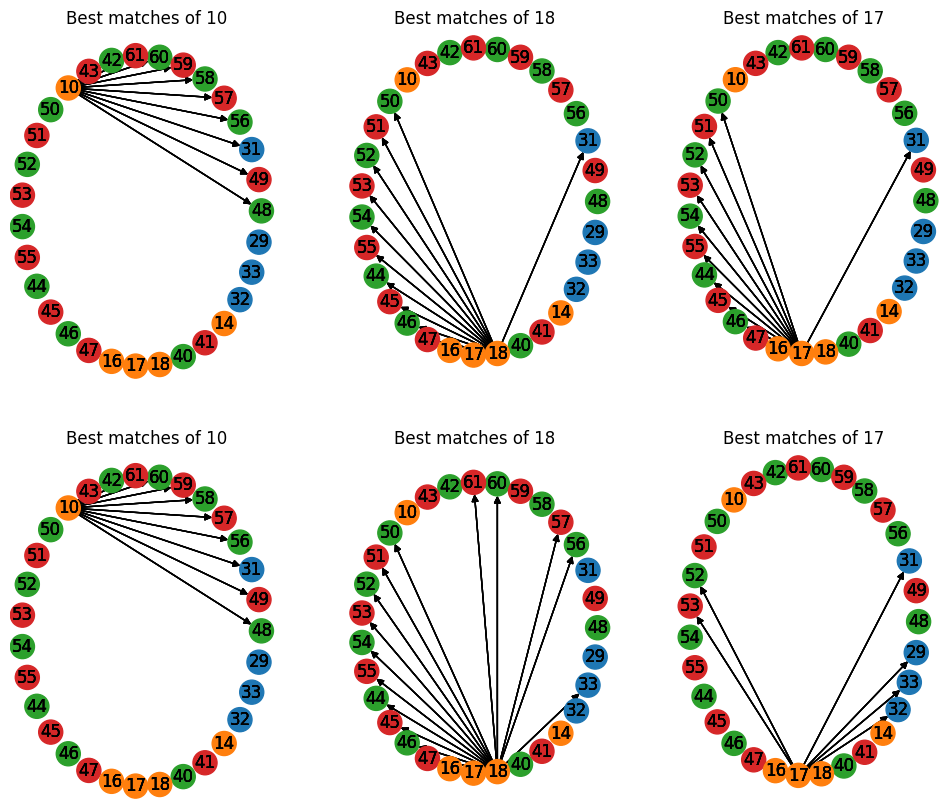

In [26]:

starting_nodes = [10, 18, 17]
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# 3 BMGs for tree
for i, starting_node in enumerate(starting_nodes):
    # create edge list for starting node
    end_nodes = BMG_tree.successors(starting_node)
    edge_list = [(starting_node,b) for b in end_nodes]
    current_ax = fig.add_subplot(gs[0, i])
    current_ax.set_title(f"Best matches of {starting_node}")
    for color, node_list in color_to_keys.items():
        nx.draw(BMG_tree, nx.circular_layout(BMG_tree), edgelist=edge_list, nodelist=node_list, node_color=[color] * len(node_list), ax=current_ax, with_labels=True)

# 3 BMGs for network
for i, starting_node in enumerate(starting_nodes):
    # create edge list for starting node
    end_nodes = BMG_network.successors(starting_node)
    edge_list = [(starting_node,b) for b in end_nodes]
    current_ax = fig.add_subplot(gs[1, i])
    current_ax.set_title(f"Best matches of {starting_node}")
    for color, node_list in color_to_keys.items():
        nx.draw(BMG_network, nx.circular_layout(BMG_network), edgelist=edge_list, nodelist=node_list, node_color=[color] * len(node_list), ax=current_ax, with_labels=True)